In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
import neurokit2 as nk

In [4]:
record = wfdb.rdrecord(
    "ptb-diagnostic-ecg-database-1.0.0/patient001/s0010_re"
)

In [5]:
signals = record.p_signal[:, :12]

In [6]:
fs = record.fs

print(fs)

1000


In [7]:
lead_ii = signals[:,1]

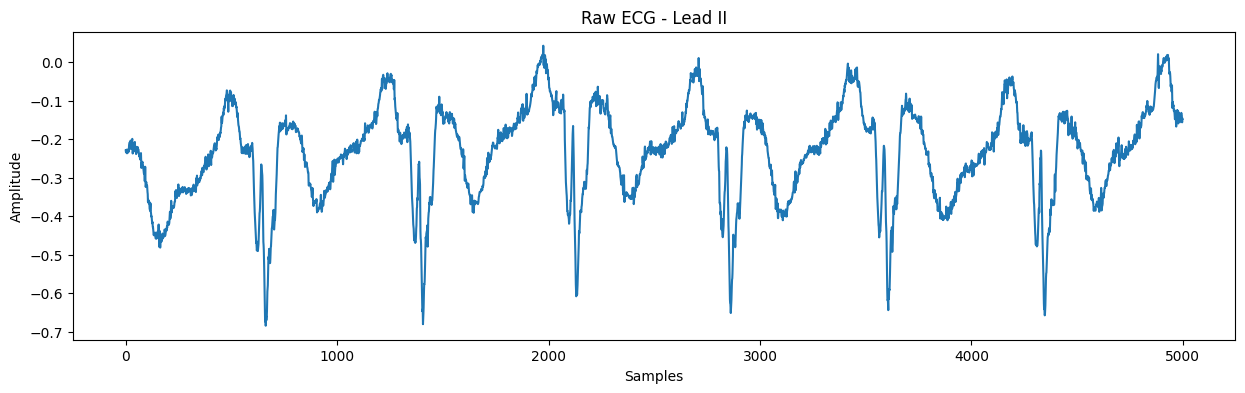

In [8]:
plt.figure(figsize=(15,4))

plt.plot(lead_ii[:5000])

plt.title("Raw ECG - Lead II")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [9]:
def bandpass_filter(signal, lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    filtered = filtfilt(b, a, signal)

    return filtered

In [10]:
filtered_ecg = bandpass_filter(
    lead_ii,
    lowcut=0.5,
    highcut=40,
    fs=fs
)

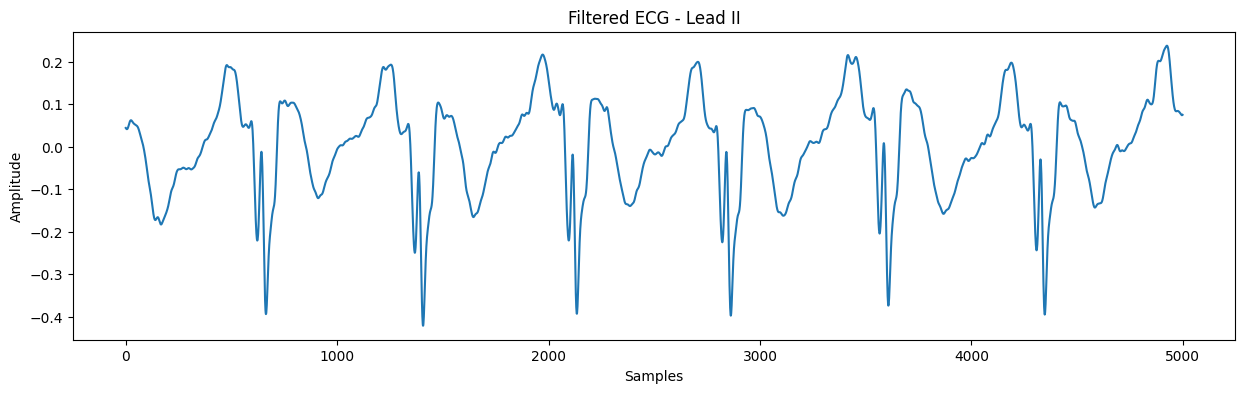

In [11]:
plt.figure(figsize=(15,4))

plt.plot(filtered_ecg[:5000])

plt.title("Filtered ECG - Lead II")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

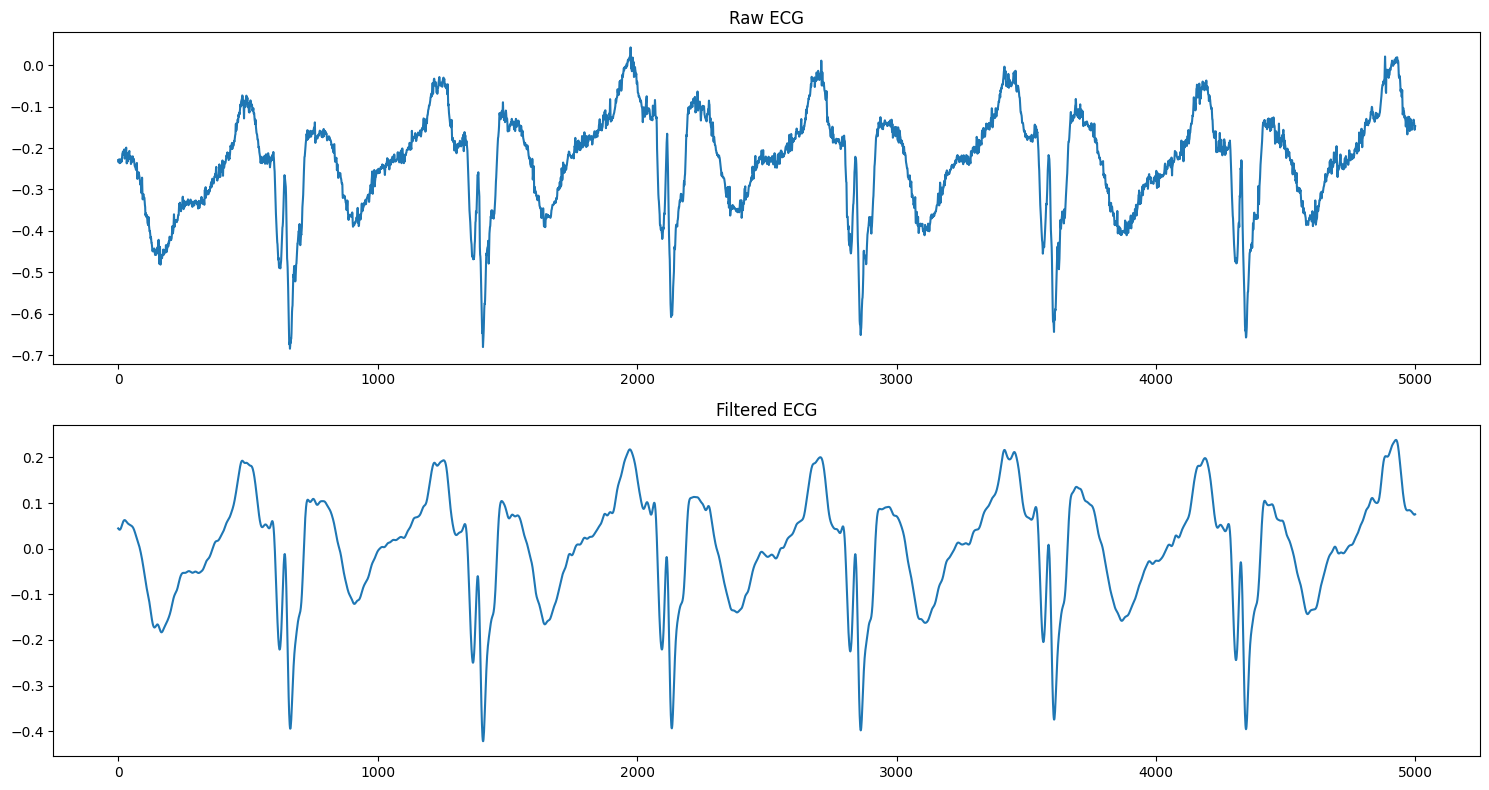

In [12]:
plt.figure(figsize=(15,8))

plt.subplot(2,1,1)
plt.plot(lead_ii[:5000])
plt.title("Raw ECG")

plt.subplot(2,1,2)
plt.plot(filtered_ecg[:5000])
plt.title("Filtered ECG")

plt.tight_layout()
plt.show()

In [13]:
normalized_ecg = (
    filtered_ecg - np.mean(filtered_ecg)
) / np.std(filtered_ecg)

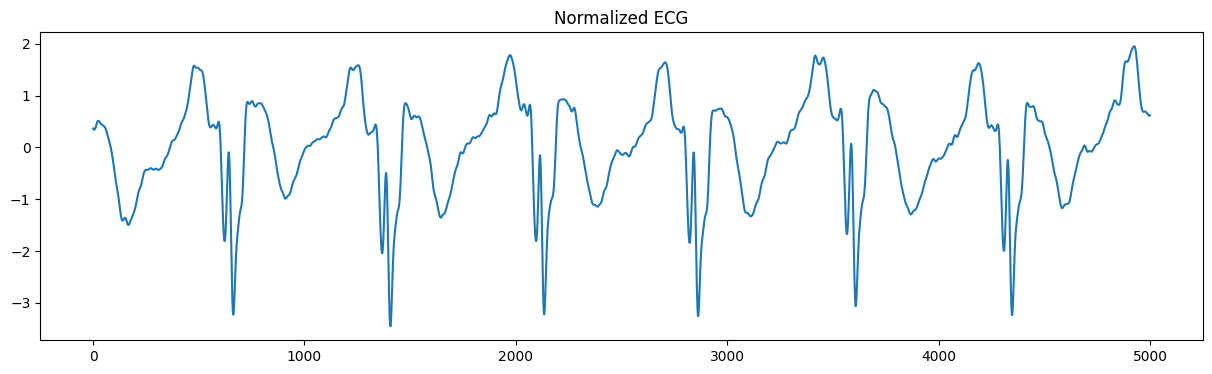

In [14]:
plt.figure(figsize=(15,4))

plt.plot(normalized_ecg[:5000])

plt.title("Normalized ECG")

plt.show()

In [15]:
cleaned_ecg = nk.ecg_clean(
    lead_ii,
    sampling_rate=fs
)

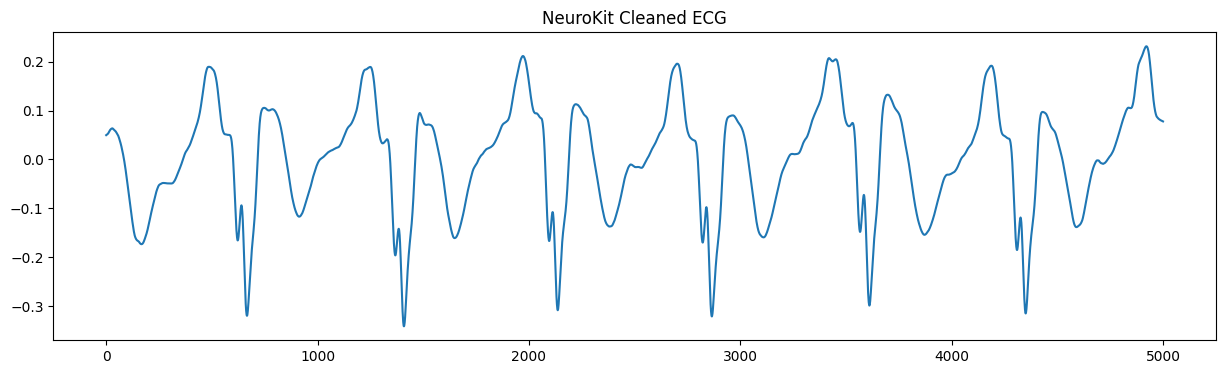

In [16]:
plt.figure(figsize=(15,4))

plt.plot(cleaned_ecg[:5000])

plt.title("NeuroKit Cleaned ECG")

plt.show()

In [17]:
signals_nk, info = nk.ecg_process(
    cleaned_ecg,
    sampling_rate=fs
)

In [18]:
r_peaks = info["ECG_R_Peaks"]

print(r_peaks[:10])

[ 636 1379 2107 2836 3581 4321 5050 5794 6535 7258]


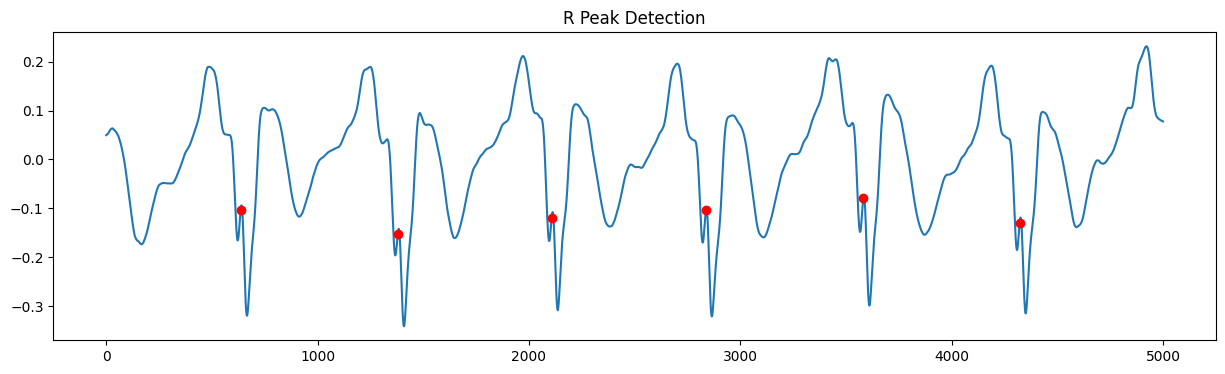

In [19]:
plt.figure(figsize=(15,4))

plt.plot(cleaned_ecg[:5000])

plt.plot(
    r_peaks[r_peaks < 5000],
    cleaned_ecg[r_peaks[r_peaks < 5000]],
    "ro"
)

plt.title("R Peak Detection")

plt.show()